In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from getdist import plots
import scienceplots
from os.path import exists
import seaborn as sns

import sys
sys.path.append("../")
from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

COLS = ['#006FED', '#E03424', 'gray', '#009966',
        '#000866', '#336600', '#006633', 'm', 'r']

In [46]:
def get_fname(catalogue, method, remove_CF4_outliers, zcmb_max=0.0501):
    return paths.flow_validation(
        fdir, "Carrick2015", catalogue=catalogue, inference_method=method,
        sample_alpha=True, sample_beta=None,
        # sample_mag_dipole=None, dust_model=None,
        mag_dipole_prior_kind="fixed" if method == "mike" and zcmb_max == 0.0501 else None,
        remove_CF4_outliers=remove_CF4_outliers,
        zcmb_max=zcmb_max)



samples = get_some_samples(get_fname("CF4_TFR_w1", "mike", True, 0.0501),
                           ["Vext", "aTFR", "bTFR", "sigma_v", "alpha", "beta"])




# samples = get_some_samples(fname, ["Vext", "mag_dipole", "aTFR"])

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_mike_zcmb_max_0.0501_sample_alpha_mag_dipole_prior_kind_fixed_remove_CF4_outliers.hdf5
Last modified: 22/02/2025 05:10:28


In [31]:
samples["beta"].mean(), samples["beta"].std()

(0.3715454, 0.019308185)

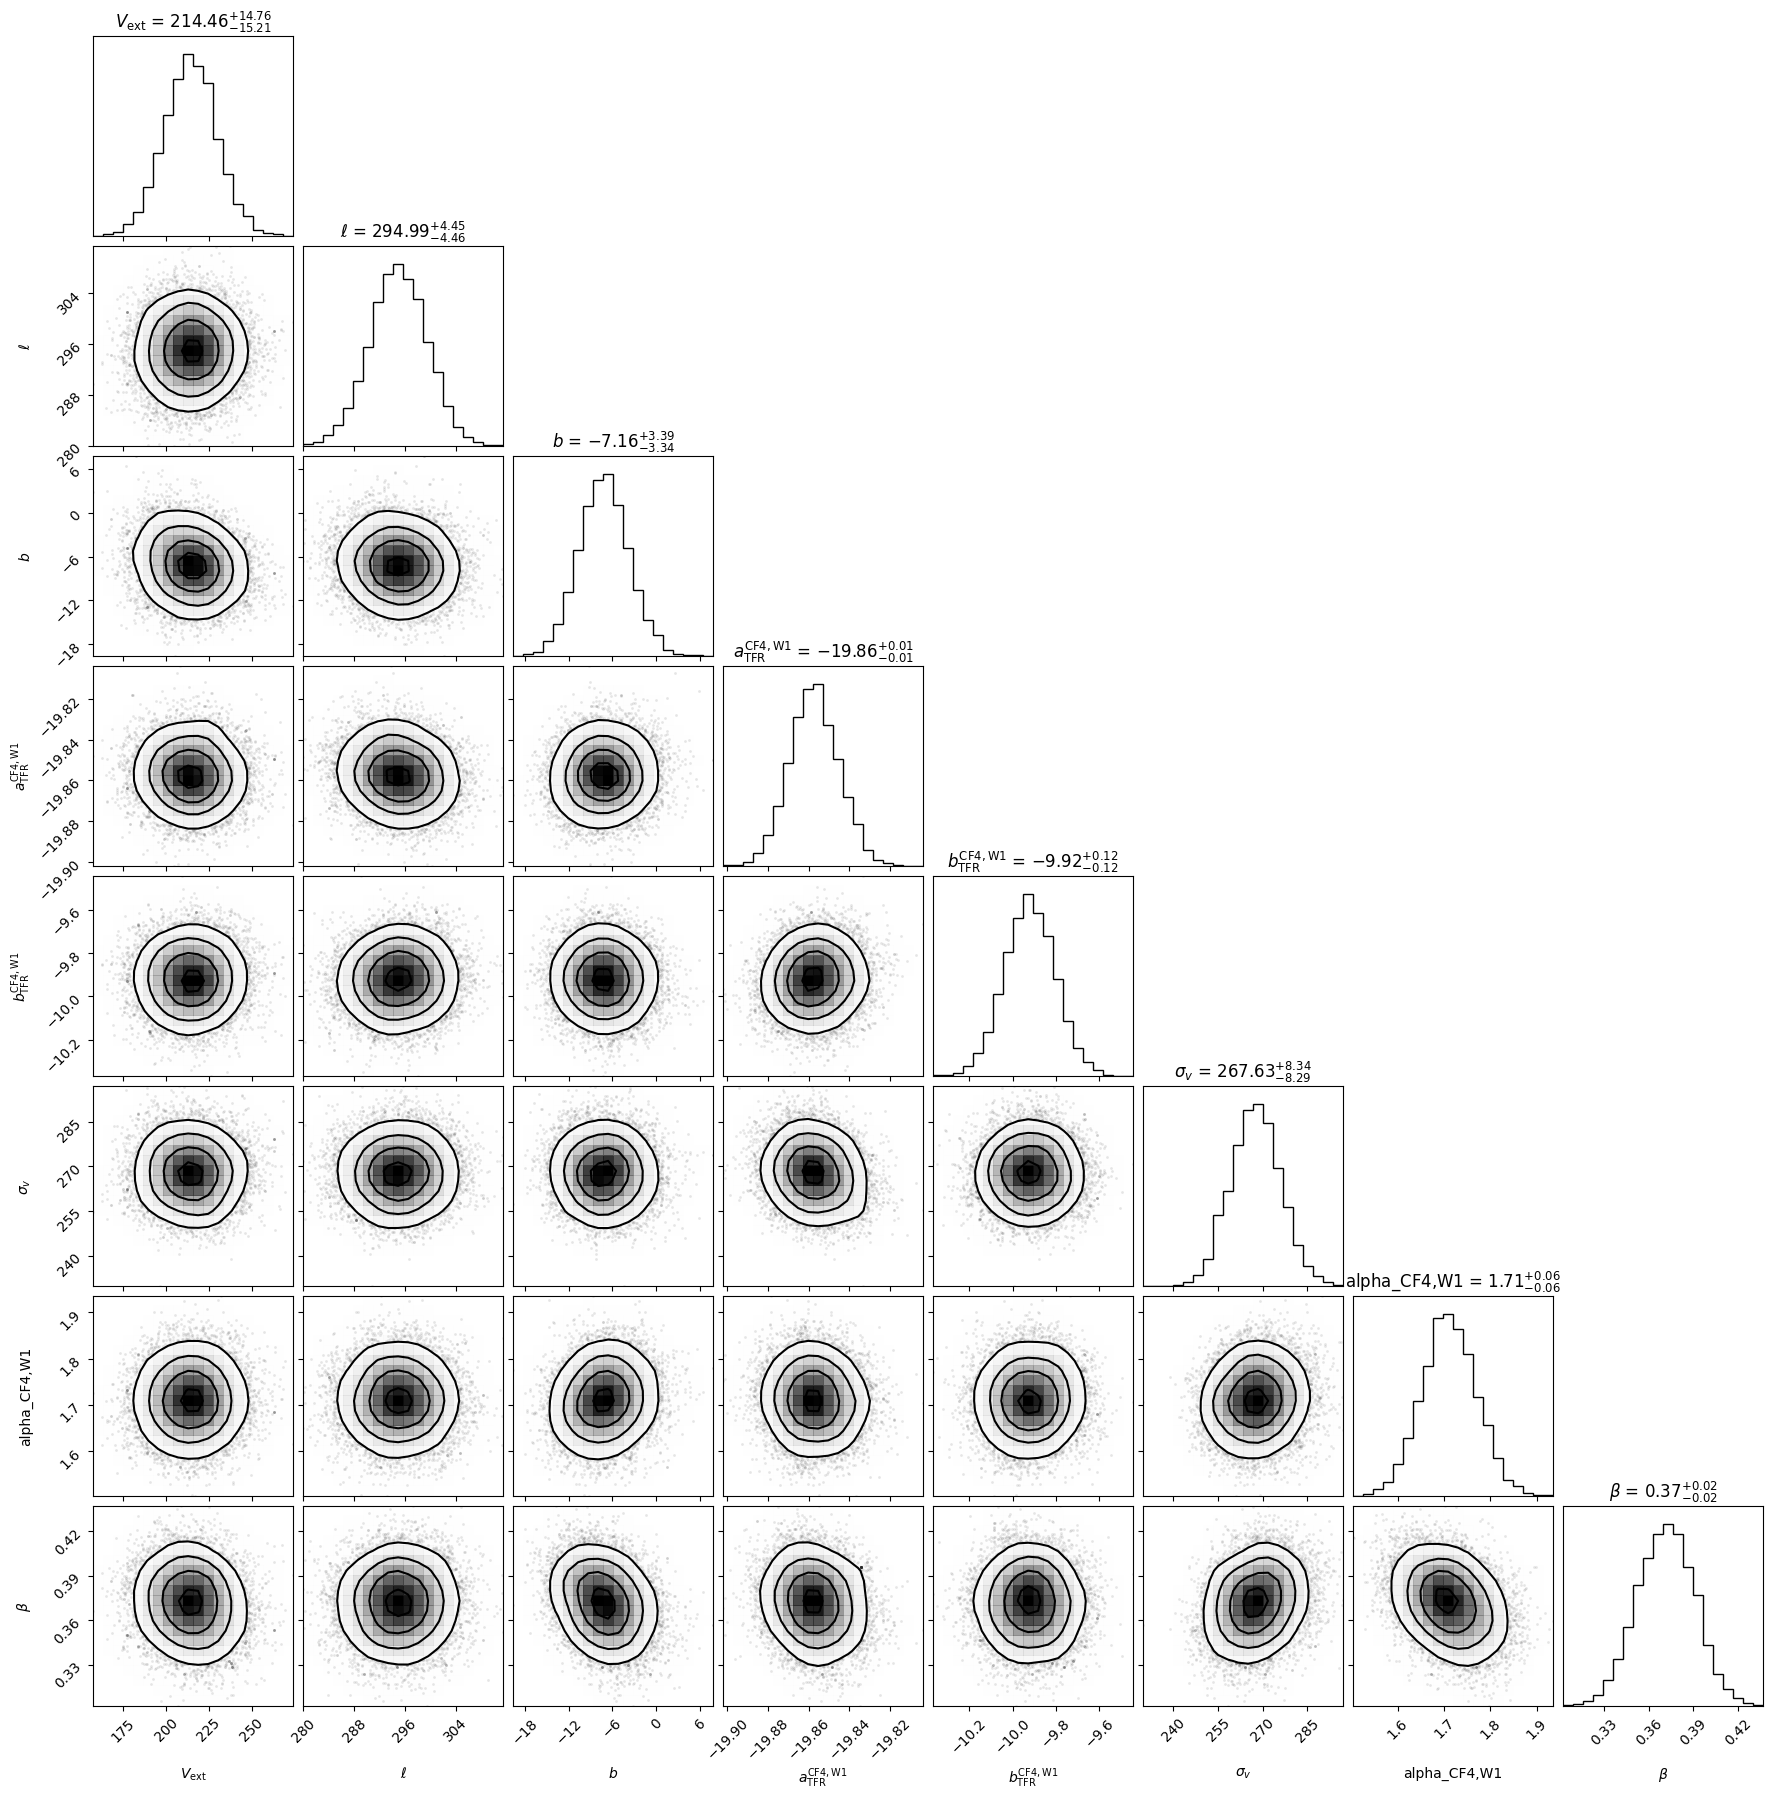

In [32]:
corner_samples, labels, keys = samples_for_corner(samples)

fig = corner(corner_samples, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)
# fig.savefig("../../../plots/corner.png", dpi=250)
fig.show()

In [47]:
X = []
catalogue = "CF4_TFR_w1"

# for remove_CF4_outliers in [False, True]:
#     samples = get_some_samples(get_fname(catalogue, "bayes", remove_CF4_outliers), ["Vext", "aTFR", "bTFR", "sigma_v", "alpha", "beta"])
# 
#     label = "Removed outliers" if remove_CF4_outliers else "All"
#     X.append(samples_to_getdist(samples, label))

for zcmb_max in [0.0501, 0.0502]:
    samples = get_some_samples(get_fname(catalogue, "mike", True, zcmb_max),
                               ["Vext", "aTFR", "bTFR", "sigma_v", "alpha", "beta"])
    X.append(samples_to_getdist(samples, rf"z_{{\rm max}} = {zcmb_max}"))

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_mike_zcmb_max_0.0501_sample_alpha_mag_dipole_prior_kind_fixed_remove_CF4_outliers.hdf5
Last modified: 22/02/2025 05:10:28
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_mike_zcmb_max_0.0502_sample_alpha_remove_CF4_outliers.hdf5
Last modified: 23/02/2025 01:37:20
Removed no burn in


/tmp/ipykernel_133116/3055264985.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


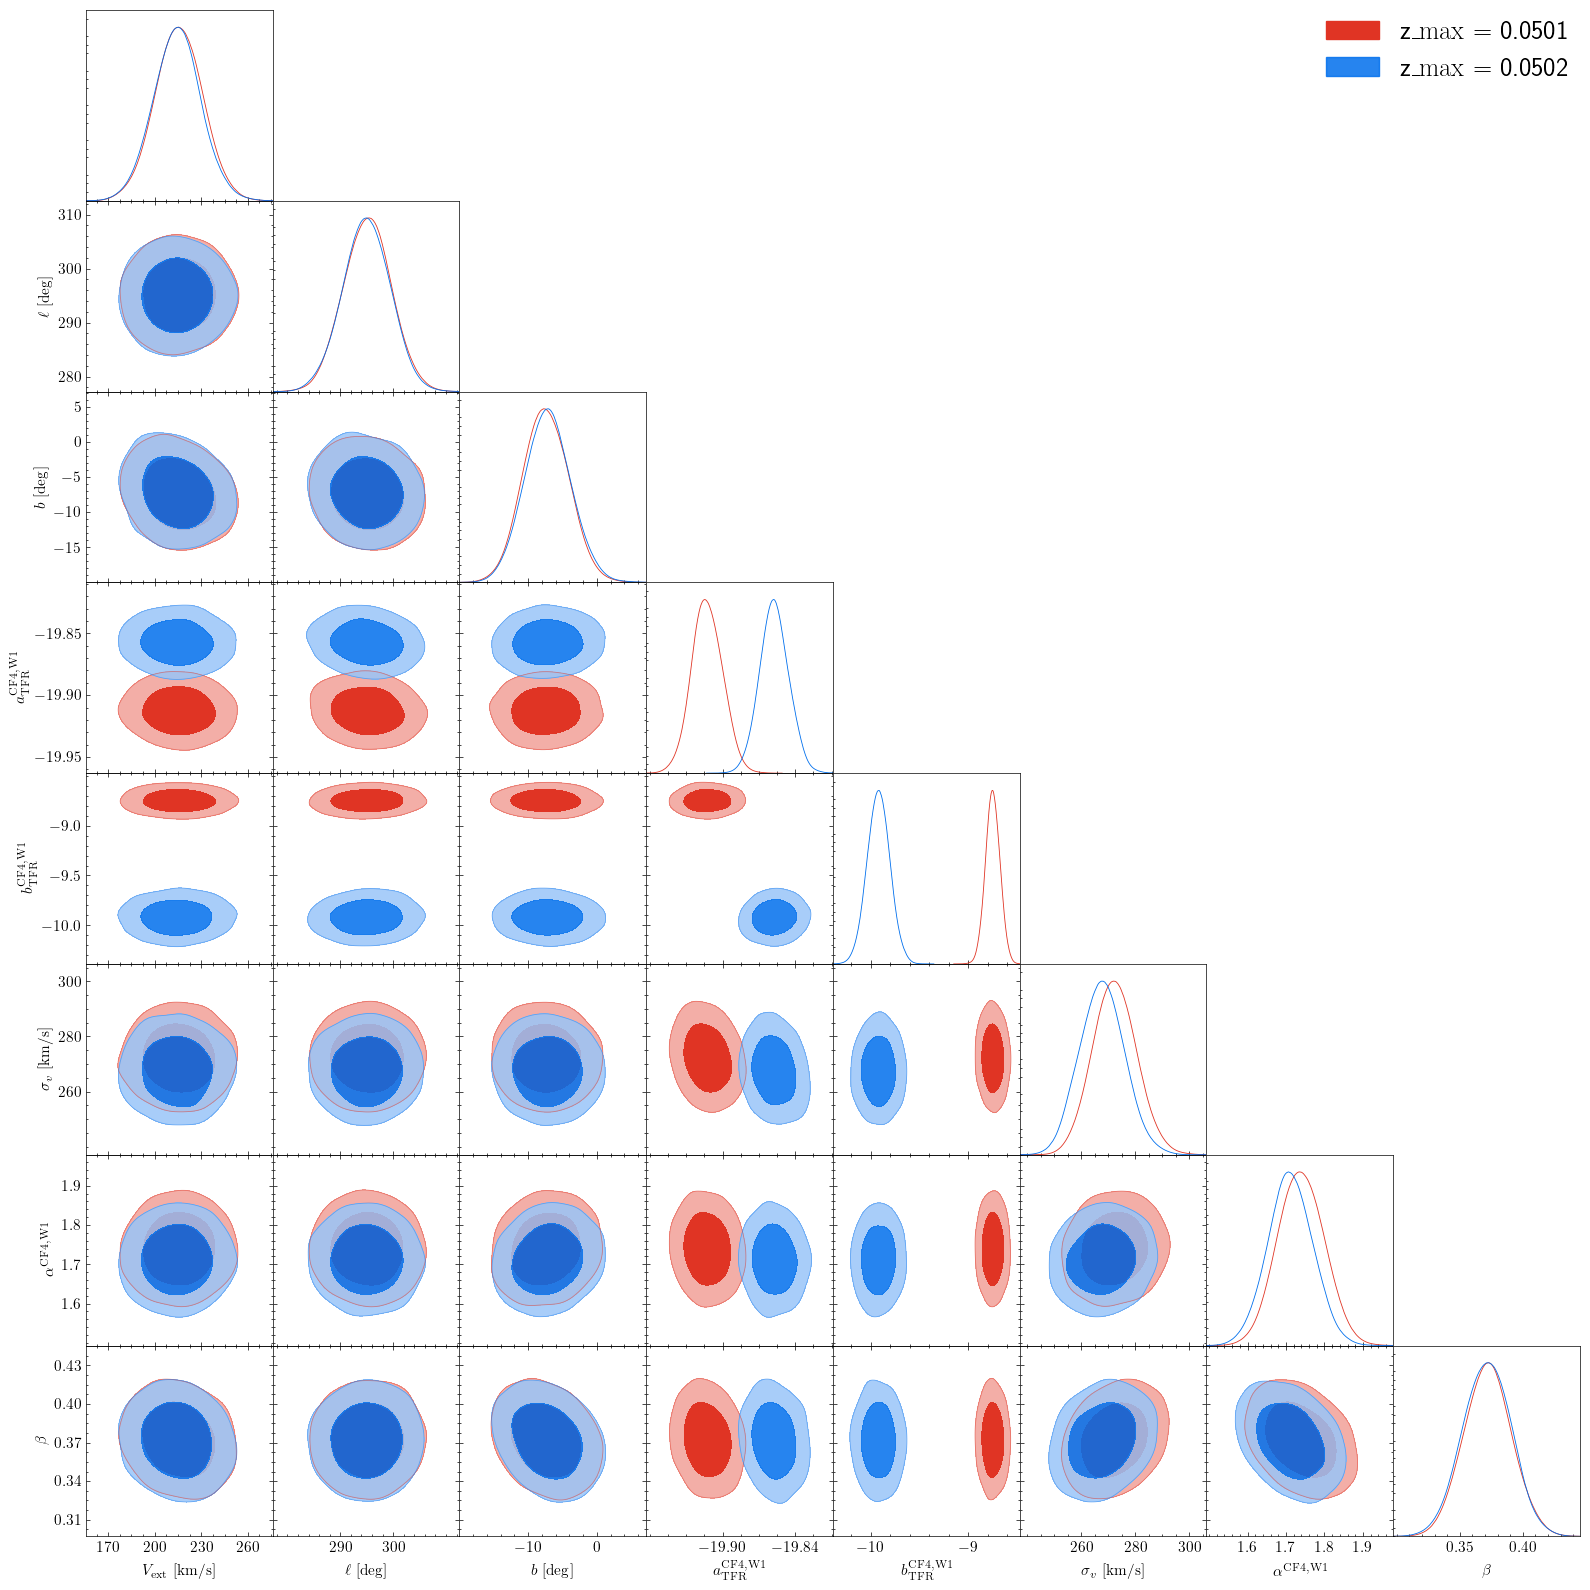

In [48]:
with plt.style.context('science'):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    # g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 22
    g.settings.axes_labelsize = 14
    g.settings.axes_fontsize = 14

    g.triangle_plot(X, filled=True, legend_loc='upper right')

    plt.gcf().tight_layout()
    # plt.gcf().savefig(f"../../../plots/flow_remove_outliers_{catalogue}.pdf", dpi=450, bbox_inches='tight')
    plt.gcf().show()
